In [1]:
import numpy as np
from numpy.linalg import norm
from scipy import spatial
import matplotlib.pyplot as plt
import math
import os

In [2]:
kv_recomp = np.load("./saved_kv/recompute.npy")
kv_reuse = np.load("./saved_kv/reuse.npy")
kv_selective = np.load("./saved_kv/selective.npy")
print(kv_recomp.shape, kv_reuse.shape, kv_selective.shape)

(32, 2, 1, 8, 378, 128) (32, 2, 1, 8, 378, 128) (32, 2, 1, 8, 378, 128)


In [3]:
print([norm(vec) for vec in kv_recomp[0, 0, 0, 0, 100:110]])
print([norm(vec) for vec in kv_selective[0, 0, 0, 0, 100:110]])
print(kv_recomp[0, 0, 0, 0, 60, :20])
print(kv_selective[0, 0, 0, 0, 60, :20])

[19.754972646728596, 19.91320194466703, 18.451784309696944, 23.35573196454217, 19.35649126818289, 19.068217141315383, 19.867059449684373, 15.774382460442139, 19.68140424219433, 20.03873516804416]
[19.722495993460633, 19.914993489975146, 18.454216771594584, 23.369697805825037, 19.370536233471935, 19.06637022770779, 19.866268947610195, 15.757625113466704, 19.65945033122361, 20.02788906246002]
[-3.203125    2.546875   -2.21875     3.125       0.03710938  1.3828125
  0.65234375  0.83203125  1.4453125  -2.359375    1.8515625  -0.58984375
  1.40625     0.12304688  1.6484375  -1.2421875   0.66015625  0.06103516
 -2.734375    0.13671875]
[-3.203125    2.53125    -2.234375    3.125       0.03637695  1.3828125
  0.65625     0.8359375   1.4453125  -2.34375     1.84375    -0.59375
  1.40625     0.12304688  1.65625    -1.2421875   0.66015625  0.06079102
 -2.734375    0.13574219]


In [4]:
def cos_distance(vec1: np.ndarray, vec2: np.ndarray):
    return spatial.distance.cosine(vec1, vec2)

def l2_distance(vec1: np.ndarray, vec2: np.ndarray):
    return norm(vec1-vec2)

In [5]:
def calc_kv_distance(kv1, kv2, layer, korv, seq, head, metric):
    kv1 = kv1[layer, korv, seq, head]
    kv2 = kv2[layer, korv, seq, head]
    dis = np.zeros((kv2.shape[0],))
    for i, (vec1, vec2) in enumerate(zip(kv1, kv2)):
        dis[i] = metric(vec1, vec2)
        # dis[i] = norm(vec1) / norm(vec2)
        # dis[i] = min(dis[i], 1.5)
    return dis

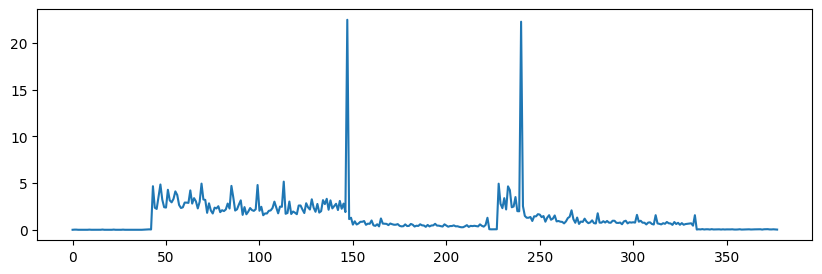

In [6]:
dis = calc_kv_distance(kv_recomp, kv_selective, 1, 0, 0, 0, l2_distance)
plt.figure(figsize=(10,3))
plt.plot(dis)
plt.show()

In [7]:
def plot_3d_kvcache_distance(cache1, cache2, metric, korv, head=0, interval=6, figname=None):
    ax = plt.figure(figsize=(20,12)).add_subplot(projection='3d')
    ax.set_box_aspect((40, 20, 16))
    ax.view_init(elev=15, azim=-80, roll=0)
    colors = plt.colormaps['viridis_r'](np.linspace(0, 1, cache1.shape[0]))
    seq_len = cache1.shape[4]
    x_indices = list(range(seq_len))
    for layer_i in reversed(range(1, cache1.shape[0], interval)):
        ax.plot(
            x_indices, 
            [layer_i] * seq_len, 
            calc_kv_distance(cache1, cache2, layer_i, korv, 0, head, metric),
            color=colors[layer_i],
        )
    if figname is not None:
        plt.savefig(os.path.join("figures", figname))
    plt.show()

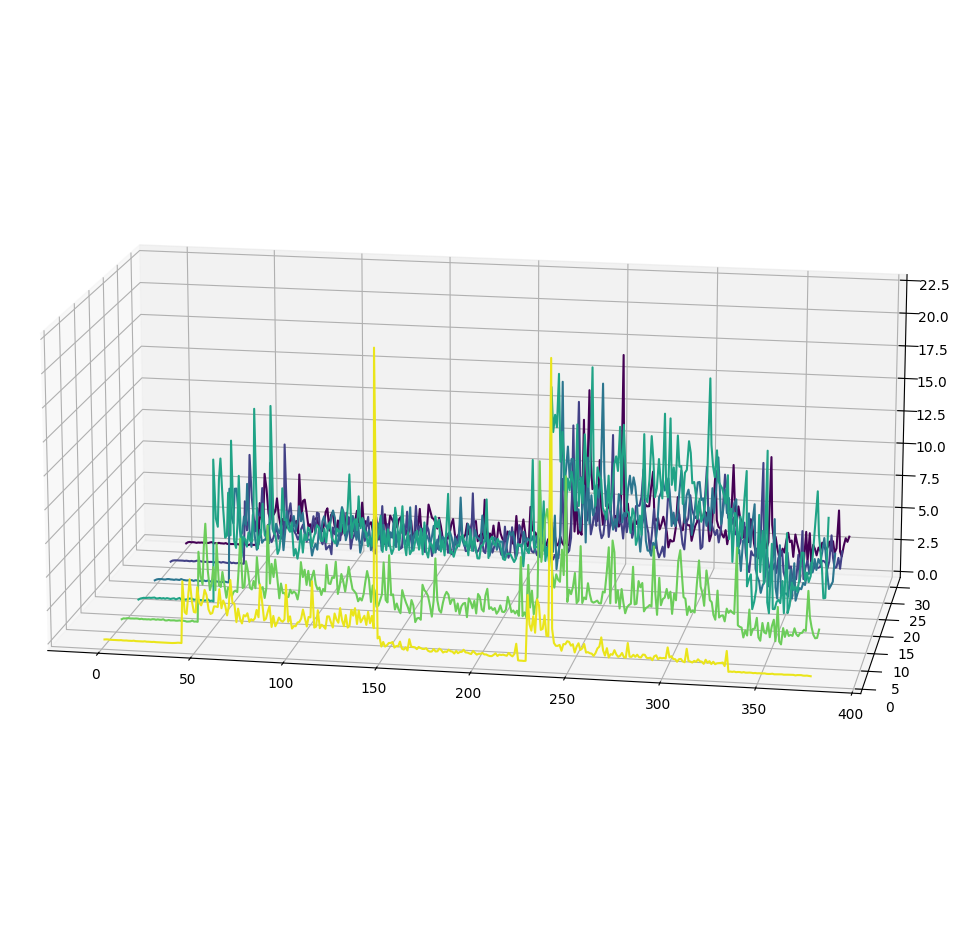

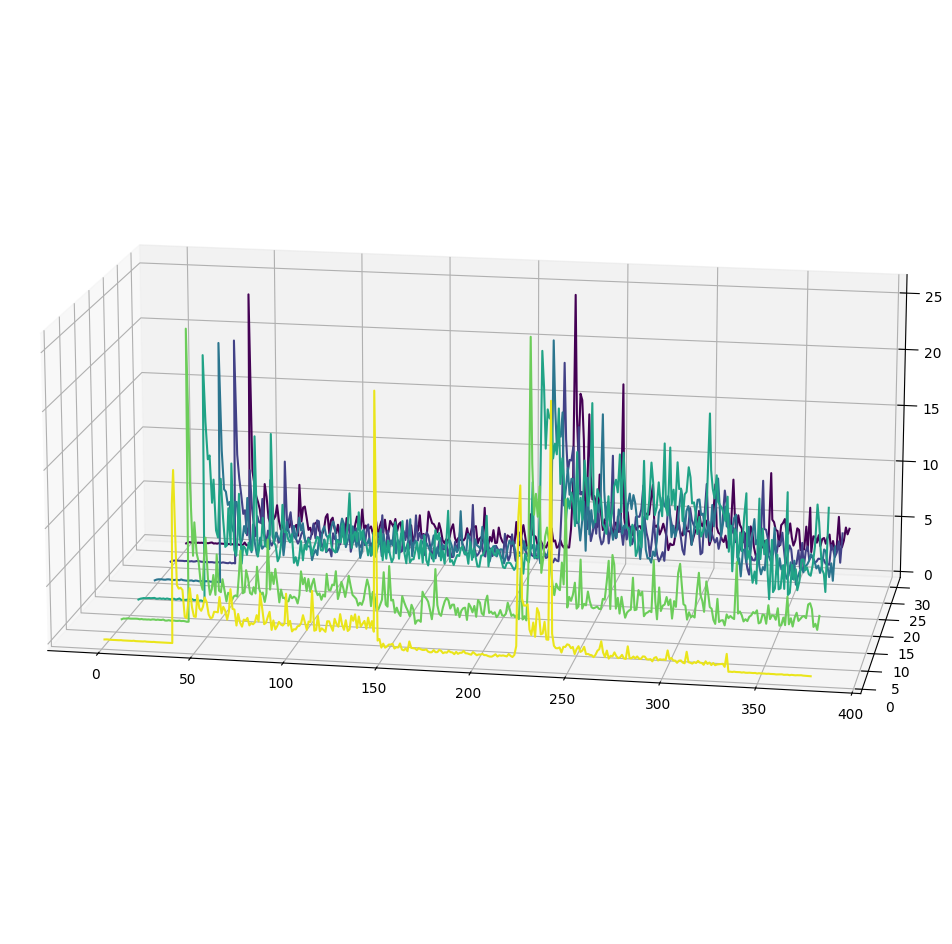

In [8]:
plot_3d_kvcache_distance(kv_recomp, kv_selective, l2_distance, 0, figname="llama3_8b-selective.png")
plot_3d_kvcache_distance(kv_recomp, kv_reuse, l2_distance, 0, figname="llama3_8b-reuse.png")